# Iris Flower Classification

## Import Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
iris = load_iris()

In [3]:
# TO check what is inside the dataset.
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


CONVERT IRIS DATASET INTO DATAFRAME.

In [4]:
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df["species"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
# To know the names.
print(iris.target_names) 

['setosa' 'versicolor' 'virginica']


## EDA(Exploratory Data Analysis)

In [6]:
# Check the number of rows and columns.
print("Shape of dataset:", df.shape)

Shape of dataset: (150, 5)


In [7]:
# TO display data types of each column
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object

In [8]:
# Check for missing values
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [9]:
# Summary statistics of numerical columns.
df.describe()  

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [10]:
# Count number of samples in each class.
df["species"].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

## DATA VISUALIZATION


In [11]:
sns.set_style("whitegrid")

### Pairplot

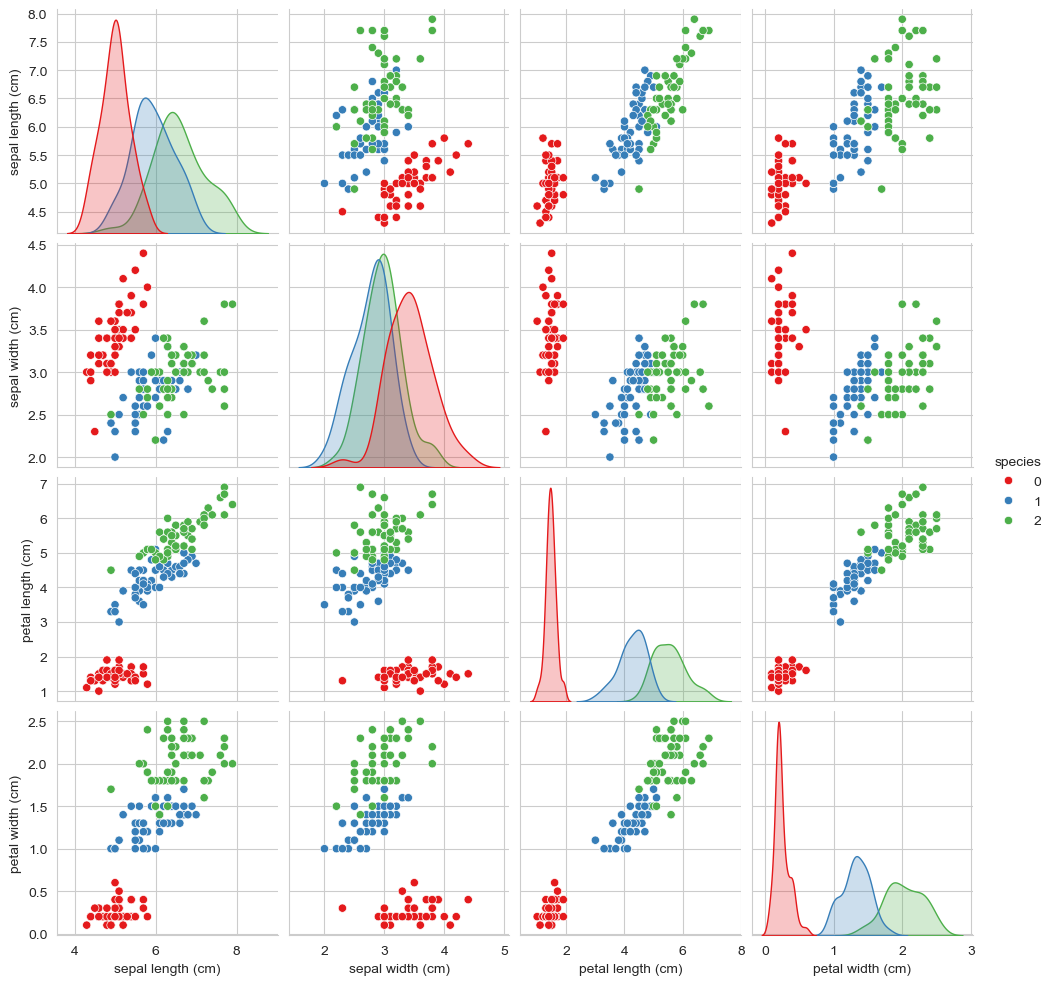

In [12]:
sns.pairplot(df, hue="species", palette="Set1")
plt.show()

### Boxplot

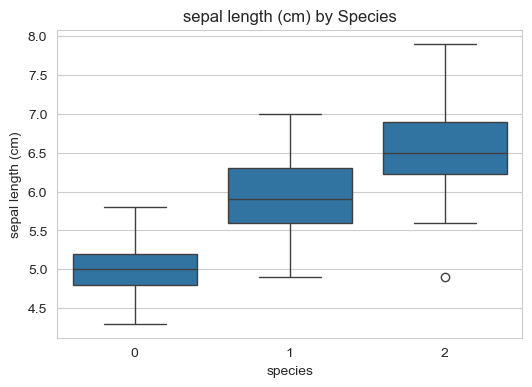

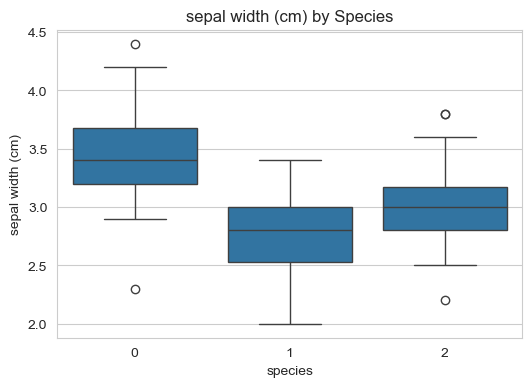

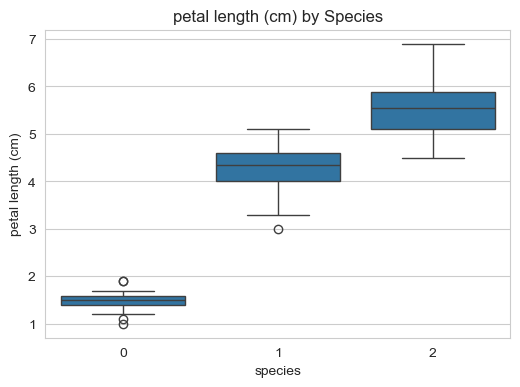

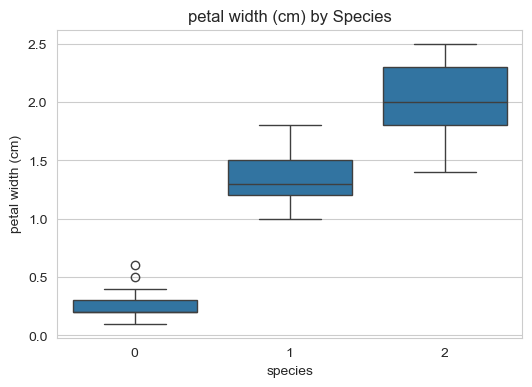

In [13]:
features = df.columns[:-1]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="species", y=feature, data=df)
    plt.title(f"{feature} by Species")
    plt.show()

### Correlation Heatmap

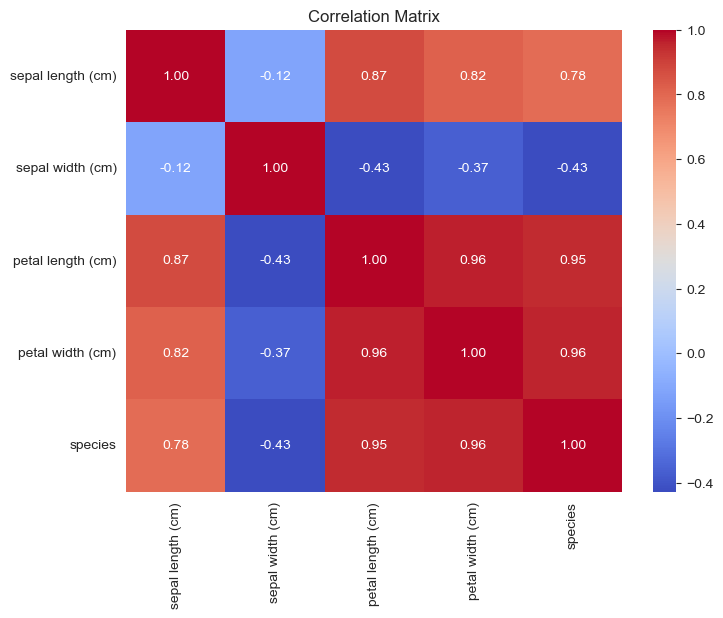

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

### Feature Selection Discussion

From the pairplot and boxplots, it is evident that petal length and petal width provide the best separation among the three Iris species. These features show minimal overlap between classes, making them the most discriminative. In contrast, sepal length and sepal width exhibit greater overlap and are therefore less effective for classification.

## Feature Selection


In [15]:
X = df.drop("species",axis=1)
y = df["species"]

### Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
# Verify the Split

print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape :", y_test.shape)

Training data shape: (120, 4)
Testing data shape : (30, 4)
Training labels shape: (120,)
Testing labels shape : (30,)


### LOGISTIC REGRESSION

In [18]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

In [19]:
# Evaluation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9666666666666667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### K-Nearest Neighbors (KNN)

In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [21]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report")
print(classification_report(y_test, y_pred_knn))

Accuracy: 1.0

Confusion Matrix
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Decision Tree


In [22]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [23]:
# Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.9333333333333333

Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [25]:
# Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9

Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



### COMPAIRING ALL MODELS

In [26]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,K-Nearest Neighbors,1.000000
0,Logistic Regression,0.966667
2,Decision Tree,0.933333
3,Random Forest,0.900000


## Conclusion

Four machine learning models were trained and evaluated on the Iris dataset:
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest

The models were evaluated using Accuracy, Confusion Matrix, Precision, Recall, and F1-score.

Among all the models, **K-Nearest Neighbours(KNN)** achieved the highest accuracy and excellent classification performance.
Therefore, it is selected as the best model for classifying Iris flower species.